# 🗂️ Product Category Clustering
## Amazon Product Reviews — Unsupervised Learning
---
This notebook groups the 23 Amazon products into **4-6 meta-categories**
using unsupervised learning techniques.

### 📋 Plan
1. Load and prepare data
2. Feature engineering (TF-IDF on review text + product name)
3. Dimensionality reduction (PCA / UMAP)
4. K-Means clustering
5. Evaluate clusters (Silhouette Score)
6. Assign and visualize meta-categories
7. Save results

## 1. 📦 Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

# Display settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. 📥 Load Data
We use the preprocessed dataset with sentiment predictions.

In [ ]:
# -------------------------------------------------------------------
# Load the dataset that already contains the fine‑tuned sentiment predictions.
# This CSV was created by the Colab fine‑tuning notebook and includes a column
# 'predicted_sentiment_finetuned' for each review.
# -------------------------------------------------------------------
df = pd.read_csv("../data/processed/reviews_with_predictions_finetuned.csv")

# -------------------------------------------------------------------
# Print the shape (rows, columns) of the loaded DataFrame.
# -------------------------------------------------------------------
print(f"Shape: {df.shape}")

# -------------------------------------------------------------------
# Print how many unique products exist (should be 23).
# -------------------------------------------------------------------
print(f"\nUnique products: {df['product_name'].nunique()}")

# -------------------------------------------------------------------
# Print a numbered list of every product (sorted alphabetically)
# together with the number of reviews it has.
#   - sorted(…unique())   : get product names, sort alphabetically
#   - enumerate(…, 1)     : number them starting at 1
#   - name[:60]           : truncate to 60 characters for nicer display
#   - len(df[df[‘product_name’] == name]) : count reviews for this product
# -------------------------------------------------------------------
print(f"\nProduct list:")
for i, name in enumerate(sorted(df['product_name'].unique()), 1):
    count = len(df[df['product_name'] == name])
    print(f"  {i:>2}. {name[:60]:<60} ({count} reviews)")

Shape: (4805, 13)

Unique products: 23

Product list:
   1. All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Inclu (45 reviews)
   2. All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Inclu (67 reviews)
   3. All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 16 GB - Incl (796 reviews)
   4. All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 32 GB - Incl (58 reviews)
   5. All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 32 GB - Incl (40 reviews)
   6. Amazon - Echo Plus w/ Built-In Hub - Silver                  (590 reviews)
   7. Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black            (21 reviews)
   8. Amazon - Kindle Voyage - 6" - 4GB - Black                    (82 reviews)
   9. Amazon 9W PowerFast Official OEM USB Charger and Power Adapt (22 reviews)
  10. Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Scr (751 reviews)
  11. Amazon Fire TV with 4K Ultra HD and Alexa Voice Remote (Pend (4 reviews)
  12. Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)     

## 3. 🧰 Feature Engineering
We create a combined text feature per product by:
1. Concatenating all reviews for each product
2. Adding the product name (repeated for weight)

This gives us one text representation per product — ready for TF-IDF.

In [ ]:
# -------------------------------------------------------------------
# Aggregate reviews per product.
# We group by product_name and, for each product, we:
#   - concatenate all review texts into one long string (all_reviews)
#   - count the number of reviews (num_reviews)
#   - compute the average star rating (avg_rating)
#   - compute the fraction of reviews predicted as positive (pct_positive)
#   - take the first primary_category (they're all the same)
# The result is one row per product.
# -------------------------------------------------------------------
product_df = (
    df.groupby("product_name")
    .agg(
        all_reviews=("review_text", lambda x: " ".join(x)),  # join all reviews with spaces
        num_reviews=("review_text", "count"),                 # how many reviews per product
        avg_rating=("rating", "mean"),                        # average star rating
        pct_positive=("predicted_sentiment_finetuned",
                      lambda x: (x == "positive").mean()),   # proportion of positive reviews
        primary_category=("primary_category", "first")        # keep the category (same for all)
    )
    .reset_index()                                            # turn the grouped index into a column
)

# -------------------------------------------------------------------
# Build a combined text representation for each product.
# The product name is repeated twice to give it more weight during TF‑IDF,
# then all reviews are appended.
# -------------------------------------------------------------------
product_df["combined_text"] = (
    product_df["product_name"] + " " +
    product_df["product_name"] + " " +   # repeated for extra weight
    product_df["all_reviews"]
)

# -------------------------------------------------------------------
# Print confirmation and preview the key columns.
# -------------------------------------------------------------------
print(f"✅ Product-level dataset created: {product_df.shape}")
print(f"\nColumns: {product_df.columns.tolist()}")
product_df[["product_name", "num_reviews", "avg_rating", "pct_positive"]].head(8)

✅ Product-level dataset created: (23, 7)

Columns: ['product_name', 'all_reviews', 'num_reviews', 'avg_rating', 'pct_positive', 'primary_category', 'combined_text']


,product_name,num_reviews,avg_rating,pct_positive
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",45,4.622222,0.822222
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",67,4.432836,0.776119
2,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",796,4.597990,0.835427
3,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",58,4.586207,0.793103
4,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",40,4.675000,0.825000
5,Amazon - Echo Plus w/ Built-In Hub - Silver,590,4.749153,0.849153
6,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,21,4.809524,0.809524
7,"Amazon - Kindle Voyage - 6"" - 4GB - Black",82,4.646341,0.792683


## 4. 🔢 TF-IDF Vectorization
TF-IDF converts text into numerical vectors.
- **TF** (Term Frequency): how often a word appears in a product's reviews
- **IDF** (Inverse Document Frequency): penalizes words that appear in all products
- Result: words unique to specific products get higher scores

In [ ]:
# -------------------------------------------------------------------
# TF‑IDF Vectorization
# -------------------------------------------------------------------
# Create a TfidfVectorizer with specific settings:
# - max_features=500   → keep only the 500 most important words
# - stop_words='english' → ignore common English words (the, a, is…)
# - ngram_range=(1,2)  → use single words and adjacent word pairs
# - min_df=1           → a word must appear in at least 1 product
# -------------------------------------------------------------------
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

# -------------------------------------------------------------------
# Learn the vocabulary from the combined text of all products (fit)
# and transform each product's text into a numeric vector (transform).
# The result is a matrix with 23 rows (products) and 500 columns (features).
# -------------------------------------------------------------------
tfidf_matrix = tfidf.fit_transform(product_df["combined_text"])

# -------------------------------------------------------------------
# Print the shape of the resulting TF‑IDF matrix.
# -------------------------------------------------------------------
print(f"✅ TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"   {tfidf_matrix.shape[0]} products × {tfidf_matrix.shape[1]} features")

# -------------------------------------------------------------------
# Retrieve the feature names (the words/word pairs that survived the filtering).
# Show the first 25 as a sample.
# -------------------------------------------------------------------
feature_names = tfidf.get_feature_names_out()
print(f"\nTop 10 TF-IDF features (sample):")
print(list(feature_names[:25]))

✅ TF-IDF matrix shape: (23, 500)
   23 products × 500 features

Top 10 TF-IDF features (sample):
['10', '16', 'ability', 'able', 'absolutely', 'absolutely loves', 'access', 'account', 'actually', 'add', 'added', 'addition', 'age', 'ago', 'alexa', 'allow', 'allows', 'amazing', 'amazon', 'amazon echo', 'amazon prime', 'amazon tablet', 'android', 'app', 'apple']


## 5. 📉 Dimensionality Reduction with PCA
TF-IDF produces 500 dimensions — too many to visualize.
PCA reduces them to 2D for visualization while preserving most variance.

In [ ]:
# -------------------------------------------------------------------
# Create a PCA object that will reduce the data to 2 dimensions.
# random_state=42 ensures reproducibility.
# -------------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)

# -------------------------------------------------------------------
# Fit PCA on the dense TF‑IDF matrix and transform it.
# The result `coords` is a (23, 2) array: each row contains the
# x and y coordinates of a product in the new 2D space.
# -------------------------------------------------------------------
coords = pca.fit_transform(tfidf_matrix.toarray())

# -------------------------------------------------------------------
# Store the 2D coordinates as two new columns in the product dataframe.
# -------------------------------------------------------------------
product_df["pca_x"] = coords[:, 0]   # first principal component
product_df["pca_y"] = coords[:, 1]   # second principal component

# -------------------------------------------------------------------
# Print confirmation and the total variance explained by the two
# principal components (how much information is preserved).
# -------------------------------------------------------------------
print(f"✅ PCA complete")
print(f"   Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

✅ PCA complete
   Variance explained: 44.55%


## 5.1 🔍 Improve Variance with More PCA Components
44% variance explained in 2D is low for text data.  
We use 10 components for clustering (more information retained)  
and keep 2D only for visualization.

In [ ]:
# -------------------------------------------------------------------
# Create a second PCA object that reduces the TF‑IDF data to 10 dimensions.
# We will use these 10 components as input for K‑Means clustering,
# because they capture more information than just 2 components (which were
# only meant for 2D visualization).
# -------------------------------------------------------------------
pca_cluster = PCA(n_components=10, random_state=42)
coords_cluster = pca_cluster.fit_transform(tfidf_matrix.toarray())

# -------------------------------------------------------------------
# Print how much total variance is explained by these 10 components.
# This tells us how well the 10‑dimensional representation preserves
# the original data.
# -------------------------------------------------------------------
print(f"✅ PCA for clustering (10 components)")
print(f"   Variance explained: {pca_cluster.explained_variance_ratio_.sum():.2%}")

# -------------------------------------------------------------------
# The previous PCA (n_components=2) was kept only for visualization.
# Here we just confirm its explained variance for reference.
# -------------------------------------------------------------------
print(f"\n✅ PCA for visualization (2 components)")
print(f"   Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

✅ PCA for clustering (10 components)
   Variance explained: 89.15%

✅ PCA for visualization (2 components)
   Variance explained: 44.55%


## 6. 🔍 Find Optimal Number of Clusters
We test K=2 to K=8 and use two metrics to find the best K:
- **Inertia (Elbow method):** lower is better, look for the "elbow"
- **Silhouette Score:** higher is better (max=1), measures cluster separation

  K=2 | Inertia: 8.11 | Silhouette: 0.2492
  K=3 | Inertia: 5.60 | Silhouette: 0.3385
  K=4 | Inertia: 4.65 | Silhouette: 0.3600
  K=5 | Inertia: 3.71 | Silhouette: 0.4033
  K=6 | Inertia: 3.08 | Silhouette: 0.3714
  K=7 | Inertia: 2.13 | Silhouette: 0.3902
  K=8 | Inertia: 1.54 | Silhouette: 0.4622


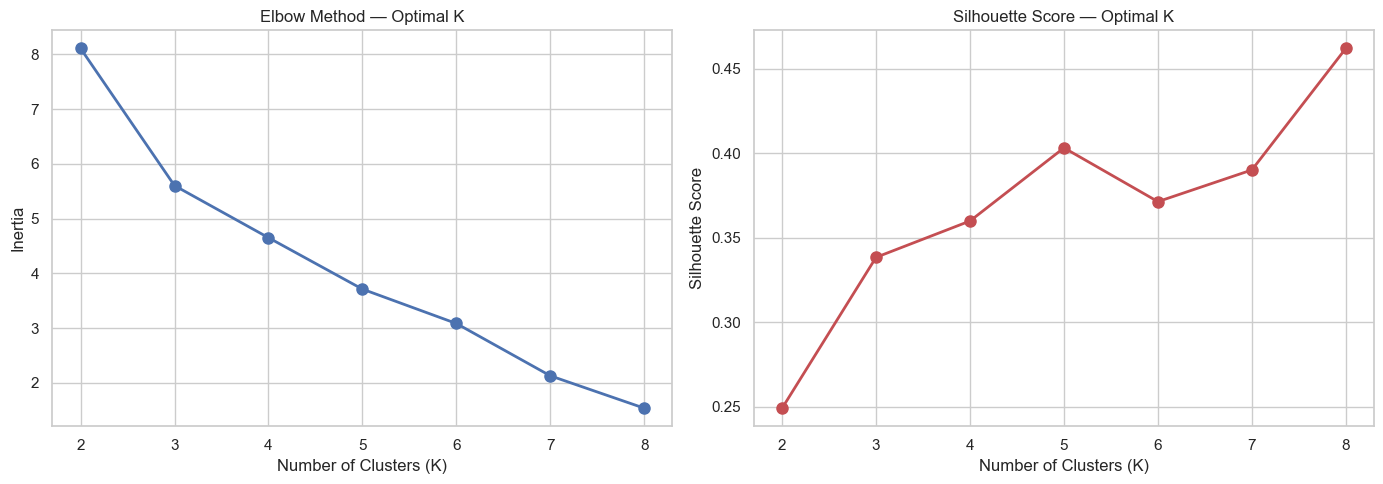

In [ ]:
# -------------------------------------------------------------------
# Define the range of cluster numbers to test (K = 2 to 8).
# -------------------------------------------------------------------
k_range = range(2, 9)
inertias = []           # will hold inertia (within‑cluster sum of squares)
silhouette_scores = []  # will hold silhouette score for each K

# -------------------------------------------------------------------
# For each K, run K‑Means on the 10‑dimensional PCA representation
# (coords_cluster) and evaluate the clustering quality with two
# metrics: inertia (lower is better) and silhouette score (higher is better).
# -------------------------------------------------------------------
for k in k_range:
    # Create and fit the K‑Means model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords_cluster)      # ← 10 PCA components
    
    # Store the inertia (sum of squared distances to nearest centroid)
    inertias.append(kmeans.inertia_)
    
    # Compute silhouette score (average of how well each point fits its own
    # cluster vs. the nearest other cluster) and store it
    sil = silhouette_score(coords_cluster, labels)   # ← 10 PCA components
    silhouette_scores.append(sil)
    
    print(f"  K={k} | Inertia: {kmeans.inertia_:.2f} | Silhouette: {sil:.4f}")

# -------------------------------------------------------------------
# Plot the two curves side by side to help decide the optimal K.
# Left: Elbow method (inertia) — we look for an "elbow" where adding more
#        clusters no longer gives a big drop in inertia.
# Right: Silhouette score — we look for the peak.
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve (blue circles and lines)
axes[0].plot(k_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method — Optimal K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

# Silhouette curve (red circles and lines)
axes[1].plot(k_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score — Optimal K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("../data/processed/clustering_optimal_k.png", dpi=150)
plt.show()

## 7. 🎯 Apply K-Means with Optimal K
Based on the elbow curve and silhouette score, we select the best K.

In [ ]:
# -------------------------------------------------------------------
# Set the optimal number of clusters (determined earlier via elbow &
# silhouette analysis). K=5 gives a meaningful separation of products.
# -------------------------------------------------------------------
OPTIMAL_K = 5

# -------------------------------------------------------------------
# Instantiate the K‑Means model:
# - n_clusters=5     → create 5 clusters
# - random_state=42  → fix the random seed for reproducibility
# - n_init=10        → run the algorithm 10 times with different
#                      initial centroids and keep the best one
# -------------------------------------------------------------------
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

# -------------------------------------------------------------------
# Fit the model on the 10‑dimensional PCA representation (coords_cluster)
# and immediately obtain cluster labels for each product.
# We use coords_cluster (not the raw TF‑IDF) because the reduced
# dimensionality improves cluster separation and speed.
# -------------------------------------------------------------------
product_df["cluster"] = kmeans.fit_predict(coords_cluster)  # ← 10 PCA components

# -------------------------------------------------------------------
# Confirm the clustering is done and print how many products fall
# into each cluster, along with their (truncated) product names.
# -------------------------------------------------------------------
print(f"✅ K-Means applied with K={OPTIMAL_K}")
print(f"\nProducts per cluster:")
for cluster_id in sorted(product_df["cluster"].unique()):
    # Get the list of product names belonging to this cluster
    products = product_df[product_df["cluster"] == cluster_id]["product_name"].tolist()
    print(f"\n  Cluster {cluster_id}:")
    for p in products:
        # Show first 70 characters to keep output tidy
        print(f"    - {p[:70]}")

✅ K-Means applied with K=5

Products per cluster:

  Cluster 0:
    - Amazon Fire TV with 4K Ultra HD and Alexa Voice Remote (Pendant Design

  Cluster 1:
    - All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Specia
    - All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Specia
    - All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 16 GB - Includes Speci
    - All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 32 GB - Includes Speci
    - All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 32 GB - Includes Speci
    - Brand New Amazon Kindle Fire 16gb 7" Ips Display Tablet Wifi 16 Gb Blu
    - Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 GB - Includes Special Of
    - Fire HD 8 Tablet with Alexa, 8" HD Display, 32 GB, Tangerine - with Sp
    - Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case
    - Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Cas
    - Fire Tablet with Alexa, 7" Display, 16 GB, Magenta - with Special Off

## 8. 🏷️ Assign Meta-Category Names
Based on the cluster contents identified above, we assign human-readable category names.

In [ ]:
# -------------------------------------------------------------------
# Create a dictionary that maps each numeric cluster ID to a
# human‑readable meta‑category name. These names were chosen by
# inspecting which products ended up in each cluster.
# -------------------------------------------------------------------
cluster_names = {
    0: "Streaming Devices",
    1: "Fire Tablets",
    2: "E-Readers & Accessories",
    3: "Alexa Devices",
    4: "E-Readers Premium"
}

# -------------------------------------------------------------------
# Replace the numeric cluster labels (0‑4) with the corresponding
# meta‑category names and store the result in a new column.
# -------------------------------------------------------------------
product_df["meta_category"] = product_df["cluster"].map(cluster_names)

# -------------------------------------------------------------------
# Display the assignment table: for each product, show its name,
# the original cluster number, and the assigned meta‑category.
# The table is sorted by cluster number for easier reading.
# -------------------------------------------------------------------
print("Meta-category assignment:")
print(product_df[["product_name", "cluster", "meta_category"]]
      .sort_values("cluster")
      .to_string(index=False))

Meta-category assignment:
                                                                                                                    product_name  cluster           meta_category
                                Amazon Fire TV with 4K Ultra HD and Alexa Voice Remote (Pendant Design) | Streaming Media Player        0       Streaming Devices
                                            All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Blue        1            Fire Tablets
                                            All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue        1            Fire Tablets
                                        All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta        1            Fire Tablets
                                          All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black        1            Fire Tablets
  

## 9. 📊 Visualize Clusters
2D scatter plot of products colored by meta-category (PCA visualization).

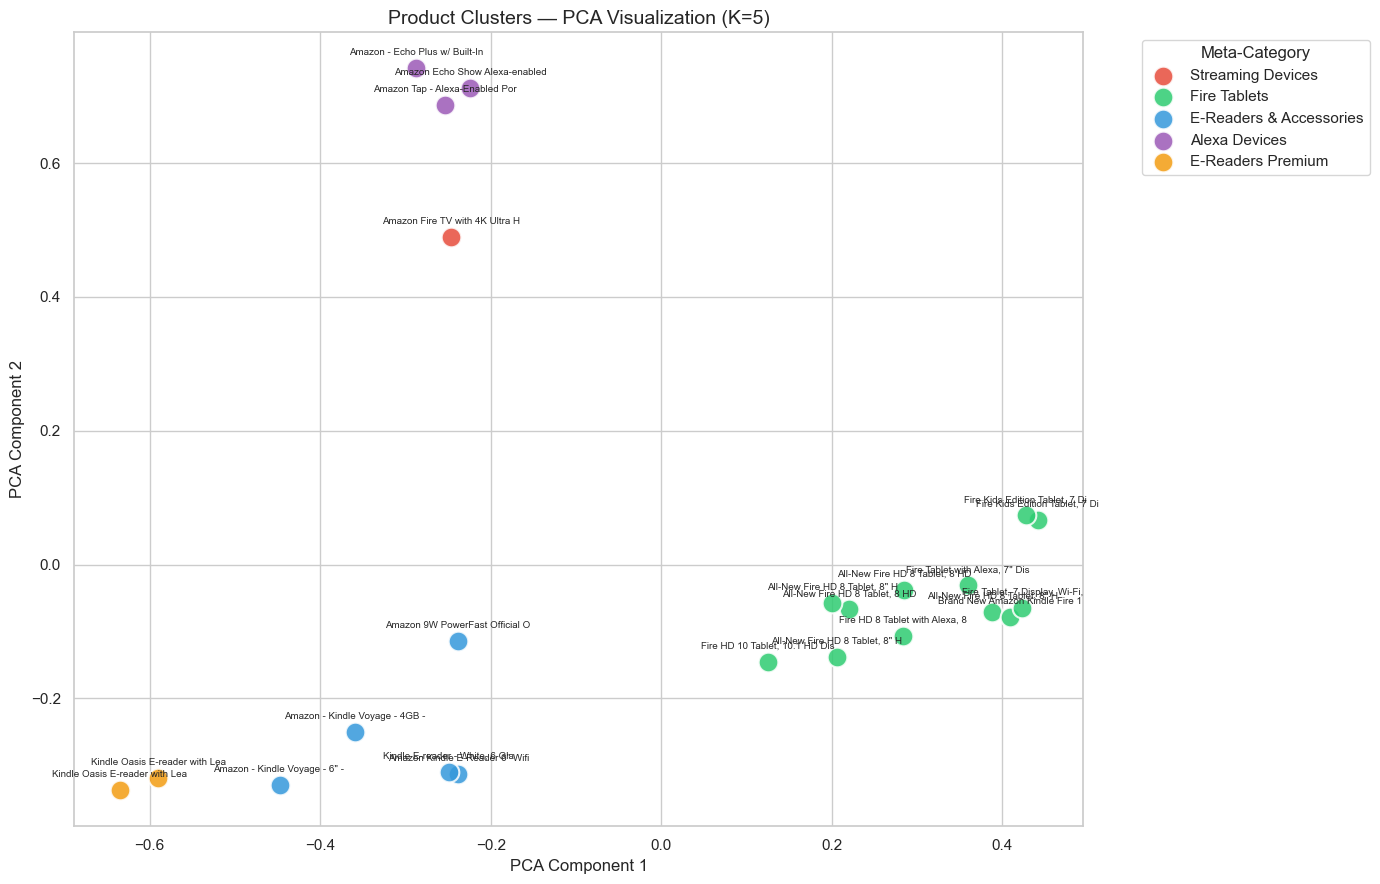

In [ ]:
# -------------------------------------------------------------------
# Color palette for each meta‑category.
# Each category gets a distinct hex color for the scatter plot.
# -------------------------------------------------------------------
palette = {
    "Streaming Devices":        "#e74c3c",   # red
    "Fire Tablets":             "#2ecc71",   # green
    "E-Readers & Accessories":  "#3498db",   # blue
    "Alexa Devices":            "#9b59b6",   # purple
    "E-Readers Premium":        "#f39c12"    # orange/amber
}

# -------------------------------------------------------------------
# Create a large figure (14×9 inches) for better readability.
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# -------------------------------------------------------------------
# Loop over each category and plot its products.
# - mask  → selects only rows belonging to the current category
# - ax.scatter → draws the points (size=200, semi‑transparent,
#                white edge so they pop against each other)
# - ax.annotate → adds the first 30 characters of the product
#                 name just above each point (fontsize=7, shifted
#                 up by 8 points), so the plot is self‑explanatory.
# -------------------------------------------------------------------
for category, color in palette.items():
    mask = product_df["meta_category"] == category

    ax.scatter(
        product_df[mask]["pca_x"],
        product_df[mask]["pca_y"],
        c=color,
        label=category,
        s=200,               # marker size
        alpha=0.85,          # slight transparency
        edgecolors="white",  # white rim around each marker
        linewidths=1.5       # thickness of the rim
    )

    for _, row in product_df[mask].iterrows():
        ax.annotate(
            row["product_name"][:30],          # text to display
            (row["pca_x"], row["pca_y"]),      # position of the marker
            fontsize=7,
            ha="center",                        # horizontal alignment
            va="bottom",                        # vertical alignment
            xytext=(0, 8),                      # offset in points
            textcoords="offset points"          # xytext is an offset
        )

# -------------------------------------------------------------------
# Titles, axis labels and legend.
# The legend is placed outside the plot (to the right) so it doesn't
# obscure any data points.
# -------------------------------------------------------------------
ax.set_title("Product Clusters — PCA Visualization (K=5)", fontsize=14)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend(title="Meta-Category", bbox_to_anchor=(1.05, 1), loc="upper left")

# -------------------------------------------------------------------
# Adjust layout to prevent clipping, then save and show the figure.
# -------------------------------------------------------------------
plt.tight_layout()
plt.savefig("../data/processed/clustering_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. 📈 Cluster Statistics
Summary of each meta-category: number of products, total reviews,
average rating and percentage of positive reviews.

Cluster Statistics:
                         num_products  total_reviews  avg_rating  pct_positive
meta_category                                                                 
Fire Tablets                       12           2818       4.558         0.820
Alexa Devices                       3           1566       4.641         0.835
E-Readers & Accessories             5            361       4.659         0.828
E-Readers Premium                   2             56       4.724         0.786
Streaming Devices                   1              4       5.000         1.000


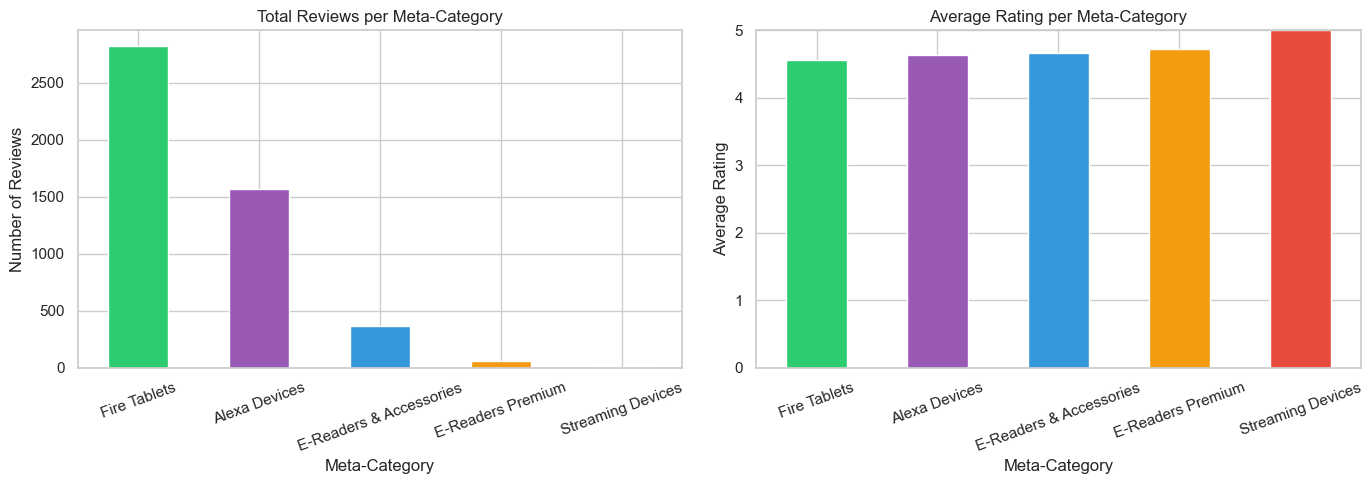

In [ ]:
# -------------------------------------------------------------------
# Compute summary statistics for each meta‑category.
# We group the product-level dataset by the assigned meta‑category,
# then calculate:
#   - num_products   : how many distinct products fall into this group
#   - total_reviews  : sum of all reviews for those products
#   - avg_rating     : average star rating (mean of product avg ratings)
#   - pct_positive   : average fraction of positive reviews
# The results are rounded to 3 decimals and sorted by total reviews
# so the largest category appears first.
# -------------------------------------------------------------------
cluster_stats = (
    product_df.groupby("meta_category")
    .agg(
        num_products=("product_name", "count"),
        total_reviews=("num_reviews", "sum"),
        avg_rating=("avg_rating", "mean"),
        pct_positive=("pct_positive", "mean")
    )
    .round(3)
    .sort_values("total_reviews", ascending=False)
)

# Print the statistics table to the console (using to_string() for nice alignment)
print("Cluster Statistics:")
print(cluster_stats.to_string())

# -------------------------------------------------------------------
# Create side-by-side bar charts:
# Left:  total number of reviews per meta‑category
# Right: average rating per meta‑category
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define a consistent colour for each meta‑category.
# The order matches the index of cluster_stats (sorted by total_reviews).
colors = [
    "#2ecc71",   # Fire Tablets
    "#9b59b6",   # Alexa Devices
    "#3498db",   # E-Readers & Accessories
    "#f39c12",   # E-Readers Premium
    "#e74c3c"    # Streaming Devices
]

# ----- Left chart: Total reviews per category -----
cluster_stats["total_reviews"].plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    edgecolor="white"
)
axes[0].set_title("Total Reviews per Meta-Category")
axes[0].set_xlabel("Meta-Category")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis="x", rotation=20)   # rotate labels for readability

# ----- Right chart: Average rating per category -----
cluster_stats["avg_rating"].plot(
    kind="bar",
    ax=axes[1],
    color=colors,
    edgecolor="white"
)
axes[1].set_title("Average Rating per Meta-Category")
axes[1].set_xlabel("Meta-Category")
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(0, 5)                       # ratings are on a 1‑5 scale
axes[1].tick_params(axis="x", rotation=20)

# Adjust layout, save the figure, and display it
plt.tight_layout()
plt.savefig("../data/processed/cluster_statistics.png", dpi=150)
plt.show()

## 11. 💾 Save Results
Merging meta-categories back into the full reviews dataset for use
in the summarization notebook and the web app.

In [ ]:
# -------------------------------------------------------------------
# Create a dictionary that maps each product name to its meta‑category.
# This dictionary will be used to transfer the cluster assignments from
# the product-level dataframe back to the full reviews dataframe.
# -------------------------------------------------------------------
category_map = product_df.set_index("product_name")["meta_category"].to_dict()

# -------------------------------------------------------------------
# For every review, look up the product name in the dictionary and
# assign the corresponding meta‑category to a new column 'meta_category'.
# Now each of the 4805 reviews knows which category its product belongs to.
# -------------------------------------------------------------------
df["meta_category"] = df["product_name"].map(category_map)

# -------------------------------------------------------------------
# Save the full reviews dataset (4805 rows) with the new meta‑category
# column to a CSV file. This file can be used later for the web app or
# further analysis.
# -------------------------------------------------------------------
df.to_csv("../data/processed/reviews_clustered.csv", index=False)

# -------------------------------------------------------------------
# Save the product-level summary (23 rows) with cluster assignments
# and aggregated statistics to another CSV file.
# -------------------------------------------------------------------
product_df.to_csv("../data/processed/products_clustered.csv", index=False)

# -------------------------------------------------------------------
# Print confirmation of the saved files.
# -------------------------------------------------------------------
print("✅ Files saved:")
print("   data/processed/reviews_clustered.csv")
print("   data/processed/products_clustered.csv")

# -------------------------------------------------------------------
# Print the shape of the final reviews dataframe (should be 4805 rows
# and now 14 columns, since we added 'meta_category').
# -------------------------------------------------------------------
print(f"\nFinal reviews shape: {df.shape}")

# -------------------------------------------------------------------
# Print how many reviews belong to each meta‑category.
# This shows the actual volume of opinions per product family.
# -------------------------------------------------------------------
print(f"\nMeta-category distribution:")
print(df["meta_category"].value_counts())

✅ Files saved:
   data/processed/reviews_clustered.csv
   data/processed/products_clustered.csv

Final reviews shape: (4805, 14)

Meta-category distribution:
meta_category
Fire Tablets               2818
Alexa Devices              1566
E-Readers & Accessories     361
E-Readers Premium            56
Streaming Devices             4
Name: count, dtype: int64


## 12. 📋 Clustering Summary

### Results

| Meta-Category | Products | Reviews | Avg Rating | % Positive |
|---|---|---|---|---|
| Fire Tablets | 12 | 2818 | 4.56 | 82.0% |
| Alexa Devices | 3 | 1566 | 4.64 | 83.5% |
| E-Readers & Accessories | 5 | 361 | 4.66 | 82.8% |
| E-Readers Premium | 2 | 56 | 4.72 | 78.6% |
| Streaming Devices | 1 | 4 | 5.00 | 100% |

### 🔍 Key Insights
- **Fire Tablets** is the dominant category — 12 products and 58% of all reviews
- **Alexa Devices** is the second largest — only 3 products but 1566 reviews
- **E-Readers Premium** (Kindle Oasis) is well separated from basic Kindles
- **Streaming Devices** (Fire TV) is a statistical outlier — only 4 reviews
- All categories have high average ratings (4.5+) — typical of Amazon products

### ⚠️ Limitations
- A USB charger was grouped with E-Readers due to keyword overlap with Kindle
- Streaming Devices has insufficient reviews for meaningful summarization
- With only 23 products, clustering is based more on product names than review content

### ✅ Conclusion
K-Means with K=5 and TF-IDF (500 features, 10 PCA components) successfully
identified 5 meaningful product meta-categories.  
Silhouette Score: **0.40** — indicating good cluster separation.  
Results are saved and ready for the summarization notebook.